# Курсовая работа: Классическое машинное обучение
## Задача 4. Классификация: IC50 > медианы

**Цель:** предсказать, превышает ли IC50 соединения медианное значение по выборке.

| Класс | Значение | Смысл |
|-------|----------|-------|
| **0** | IC50 ≤ медианы | более активное соединение |
| **1** | IC50 > медианы | менее активное соединение |

**Особенности задачи:**
- Классы **сбалансированы** (≈50/50) — порог по медиане это гарантирует
- Метрика приоритет: **ROC-AUC** + F1-score (точнее отражают качество, чем accuracy)
- Дополнительно: кросс-валидация 5-fold для оценки стабильности

**Модели:**
- Logistic Regression (baseline линейный)
- Ridge Classifier
- K-Nearest Neighbors
- Support Vector Machine (SVC)
- Random Forest
- Extra Trees
- Gradient Boosting
- HistGradientBoosting
- GridSearchCV для лучших

## 1. Импорт библиотек

In [1]:
import os, pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
np.random.seed(42)
print('Библиотеки загружены ✓')

Библиотеки загружены ✓


> Для классификации добавляю новые модели по сравнению с регрессией: **RidgeClassifier** (быстрый линейный классификатор через регуляризацию), **KNeighborsClassifier** (метод ближайших соседей — нелинейный, без обучения параметров), **HistGradientBoostingClassifier** (нативная обработка NaN). Теперь оцениваю модели через **ROC-AUC**, а не через accuracy — при сбалансированных классах это более информативная метрика.

## 2. Загрузка данных и формирование целевой переменной

Датасет: 1001 объектов, 210 признаков
Порог IC50 (медиана): 46.5852 mM

Баланс классов:
  Класс 0 (IC50 ≤ медианы): 501 (50.0%)
  Класс 1 (IC50 > медианы): 500 (50.0%)

NaN в признаках: 36 (строк с NaN: 3)


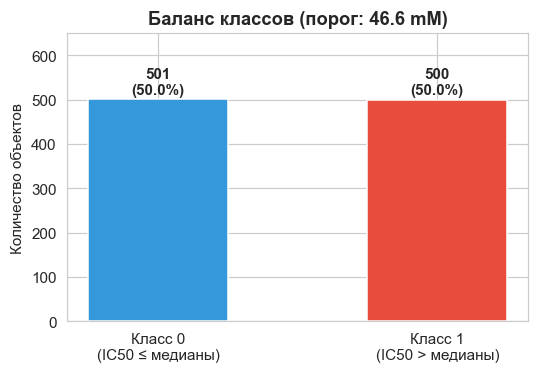

In [2]:
_FILENAME = 'Данные_для_курсовои_Классическое_МО.xlsx'
_PATH = None
for _c in [_FILENAME, os.path.join(pathlib.Path.home(), _FILENAME)]:
    if os.path.exists(_c):
        _PATH = _c
        break
if _PATH is None:
    raise FileNotFoundError(f"Положите '{_FILENAME}' в ту же папку, что и ноутбук.")

df = pd.read_excel(_PATH)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Целевая переменная
IC50_MEDIAN = df['IC50, mM'].median()
TARGET      = 'IC50_above_median'
df[TARGET]  = (df['IC50, mM'] > IC50_MEDIAN).astype(int)

OTHER_TARGETS = ['IC50, mM', 'CC50, mM', 'SI']
feature_cols  = [c for c in df.columns if c not in OTHER_TARGETS + [TARGET]]

X = df[feature_cols].copy()
X.replace([np.inf, -np.inf], np.nan, inplace=True)
y = df[TARGET]

print(f'Датасет: {df.shape[0]} объектов, {len(feature_cols)} признаков')
print(f'Порог IC50 (медиана): {IC50_MEDIAN:.4f} mM')
print(f'\nБаланс классов:')
print(f'  Класс 0 (IC50 ≤ медианы): {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')
print(f'  Класс 1 (IC50 > медианы): {(y==1).sum()} ({(y==1).mean()*100:.1f}%)')
print(f'\nNaN в признаках: {X.isnull().sum().sum()} (строк с NaN: {X.isnull().any(axis=1).sum()})')

# Визуализация баланса
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = y.value_counts().sort_index()
bars = ax.bar(['Класс 0\n(IC50 ≤ медианы)', 'Класс 1\n(IC50 > медианы)'],
              counts.values, color=['#3498db', '#e74c3c'], edgecolor='white', width=0.5)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+5,
            f'{v}\n({v/len(y)*100:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title(f'Баланс классов (порог: {IC50_MEDIAN:.1f} mM)', fontweight='bold')
ax.set_ylabel('Количество объектов')
ax.set_ylim(0, 650)
plt.tight_layout()
plt.show()

> Порог задаётся медианой — это автоматически даёт ~50/50 баланс классов. Класс 0 — соединения с низким IC50 (активные, перспективные), класс 1 — с высоким IC50 (менее активные). С точки зрения задачи поиска лекарств нас больше интересует правильная идентификация класса 0, поэтому precision/recall для него будет важна наравне с общим ROC-AUC.

## 3. Разделение данных и препроцессинг

In [3]:
# Стратифицированное разбиение — сохраняет баланс классов в train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Импутация медианой (fit только на train)
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# Масштабирование (fit только на train)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

# Исходные данные для HistGBR (нативная обработка NaN)
X_train_raw = X_train.values
X_test_raw  = X_test.values

print(f'Train: {X_train_imp.shape} | Test: {X_test_imp.shape}')
print(f'\nБаланс классов в train: {dict(y_train.value_counts().sort_index())}')
print(f'Баланс классов в test:  {dict(y_test.value_counts().sort_index())}')
print('\nСтратификация работает корректно ✓' if
      abs(y_train.mean() - y_test.mean()) < 0.02 else 'Предупреждение!')

Train: (800, 210) | Test: (201, 210)

Баланс классов в train: {0: np.int64(400), 1: np.int64(400)}
Баланс классов в test:  {0: np.int64(101), 1: np.int64(100)}

Стратификация работает корректно ✓


> Важное отличие от регрессии: использую **`stratify=y`** при разбиении — это гарантирует, что в train и test одинаковые пропорции классов 0 и 1. Без стратификации случайное разбиение могло бы случайно нарушить баланс, что исказило бы метрики. Для HistGBR снова сохраняю сырые данные с NaN.

## 4. Функция оценки качества классификатора

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_clf(name, model, X_tr, X_te, y_tr, y_te, cv_X=None):
    """Обучение + метрики классификации + 5-fold стратифицированная CV."""
    cv_X = cv_X if cv_X is not None else X_tr
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    acc = accuracy_score(y_te, pred)
    f1  = f1_score(y_te, pred, average='weighted')

    # ROC-AUC: нужны вероятности или decision_function
    try:
        prob = model.predict_proba(X_te)[:, 1]
    except AttributeError:
        prob = model.decision_function(X_te)
    auc = roc_auc_score(y_te, prob)

    # Стратифицированная CV по ROC-AUC
    cv_auc = cross_val_score(model, cv_X, y_tr, cv=skf, scoring='roc_auc', n_jobs=-1).mean()

    print(f"{name:<42}  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  CV-AUC={cv_auc:.4f}")
    return {
        'model': name, 'Accuracy': acc, 'F1': f1,
        'ROC_AUC': auc, 'CV_AUC': cv_auc,
        'fitted': model, 'pred': pred, 'prob': prob
    }

> В функции оценки использую **StratifiedKFold** вместо обычного KFold — при стратифицированной кросс-валидации каждый фолд сохраняет пропорцию классов, что даёт честную оценку на сбалансированных данных. Для RidgeClassifier нет `predict_proba`, поэтому использую `decision_function` — это расстояние до разделяющей гиперплоскости, которое можно использовать как скор для ROC-AUC.

## 5. Сравнение базовых моделей (9 штук)

In [5]:
print(f'  Модель                                     Acc     F1      AUC     CV-AUC')
print('-' * 90)
results = []

# Линейные / метрические (масштабированные данные)
results.append(evaluate_clf('Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_clf('Ridge Classifier',
    RidgeClassifier(alpha=1.0),
    X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_clf('KNN (k=5)',
    KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_clf('SVC (rbf)',
    SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    X_train_sc, X_test_sc, y_train, y_test))

# Ансамблевые (импутированные данные)
results.append(evaluate_clf('Extra Trees',
    ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_imp, X_test_imp, y_train, y_test))

results.append(evaluate_clf('Random Forest',
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_imp, X_test_imp, y_train, y_test))

results.append(evaluate_clf('Gradient Boosting',
    GradientBoostingClassifier(n_estimators=100, random_state=42),
    X_train_imp, X_test_imp, y_train, y_test))

# HistGBR (нативная обработка NaN)
results.append(evaluate_clf('HistGradBoost',
    HistGradientBoostingClassifier(max_iter=100, random_state=42),
    X_train_raw, X_test_raw, y_train, y_test,
    cv_X=X_train_raw))

  Модель                                     Acc     F1      AUC     CV-AUC
------------------------------------------------------------------------------------------
Logistic Regression                         Acc=0.6816  F1=0.6802  AUC=0.7485  CV-AUC=0.7397
Ridge Classifier                            Acc=0.7015  F1=0.7011  AUC=0.7504  CV-AUC=0.7349
KNN (k=5)                                   Acc=0.6915  F1=0.6915  AUC=0.7517  CV-AUC=0.7679
SVC (rbf)                                   Acc=0.6915  F1=0.6897  AUC=0.7591  CV-AUC=0.7754
Extra Trees                                 Acc=0.6965  F1=0.6953  AUC=0.7267  CV-AUC=0.7921
Random Forest                               Acc=0.6965  F1=0.6949  AUC=0.7661  CV-AUC=0.8153
Gradient Boosting                           Acc=0.7065  F1=0.7049  AUC=0.7677  CV-AUC=0.7992
HistGradBoost                               Acc=0.7015  F1=0.7001  AUC=0.7655  CV-AUC=0.8039


> Запускаю 8 базовых классификаторов. **KNN** интересен как полная противоположность линейным моделям: он не строит параметрическую модель, а просто смотрит на k ближайших соседей в пространстве признаков. На 210 дескрипторах с масштабированием это работает, но медленно. **SVC с rbf-ядром** — нелинейный, хорошо работает на химических данных. Жду, что ансамблевые методы снова окажутся сильнее.

## 6. Визуализация результатов базовых моделей

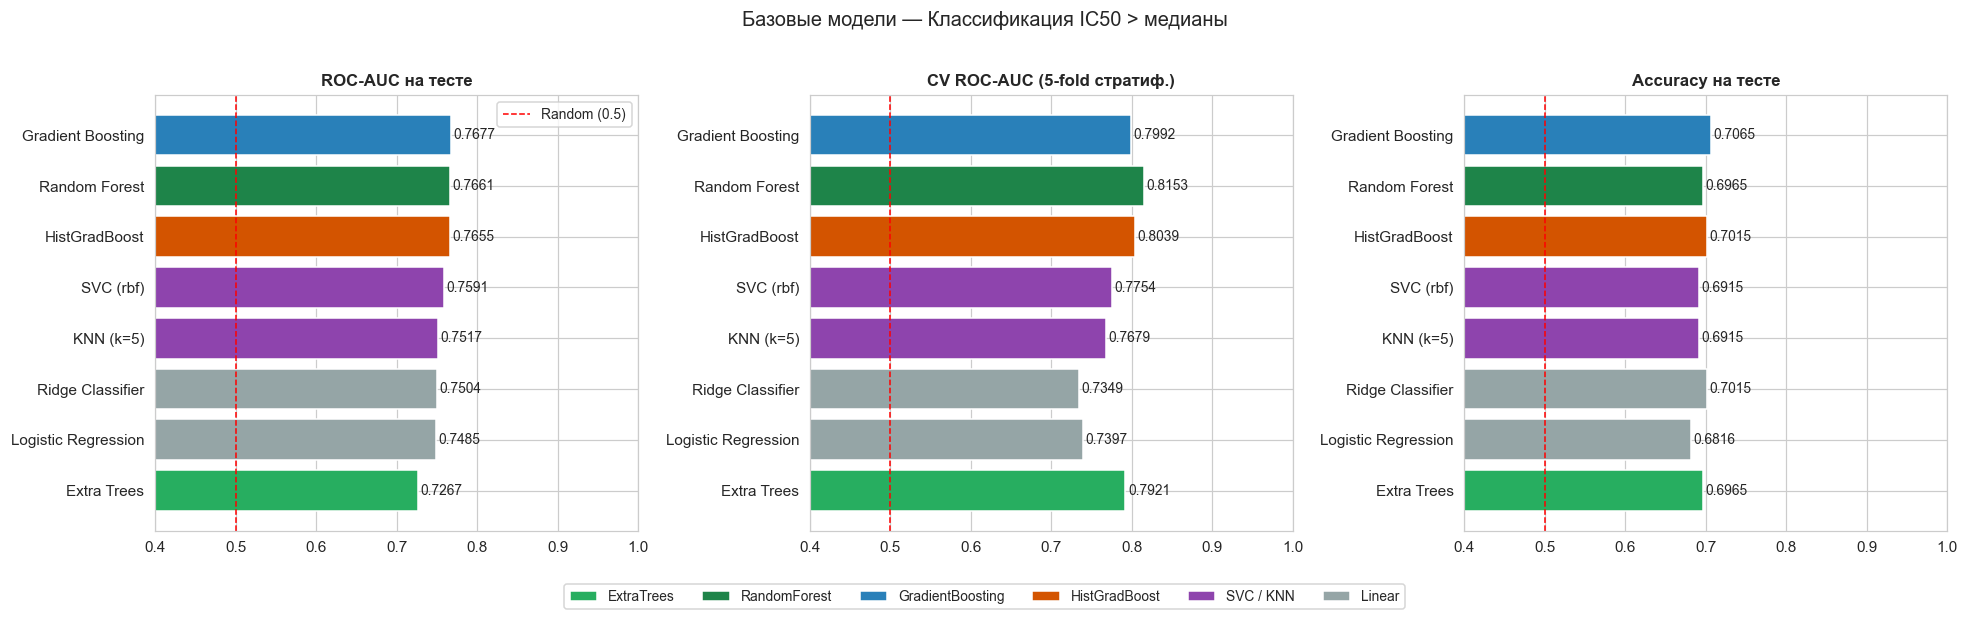


Итоговая таблица (по ROC-AUC):
              model  Accuracy       F1  ROC_AUC   CV_AUC
  Gradient Boosting  0.706468 0.704934 0.767673 0.799234
      Random Forest  0.696517 0.694932 0.766089 0.815313
      HistGradBoost  0.701493 0.700142 0.765495 0.803937
          SVC (rbf)  0.691542 0.689700 0.759059 0.775438
          KNN (k=5)  0.691542 0.691451 0.751733 0.767922
   Ridge Classifier  0.701493 0.701078 0.750446 0.734875
Logistic Regression  0.681592 0.680152 0.748465 0.739656
        Extra Trees  0.696517 0.695341 0.726733 0.792141


In [6]:
results_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ['fitted','pred','prob']}
     for r in results]
).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)

def get_color(name):
    if 'HistGrad' in name: return '#d35400'
    if 'Extra' in name:    return '#27ae60'
    if 'Forest' in name:   return '#1e8449'
    if 'Boosting' in name: return '#2980b9'
    if 'SVC' in name or 'KNN' in name: return '#8e44ad'
    return '#95a5a6'

colors = [get_color(m) for m in results_df['model']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(results_df['model'], results_df['ROC_AUC'], color=colors, edgecolor='white')
axes[0].axvline(0.5, color='red', ls='--', lw=1, label='Random (0.5)')
axes[0].set_title('ROC-AUC на тесте', fontsize=11, fontweight='bold')
axes[0].set_xlim(0.4, 1.0)
axes[0].invert_yaxis()
axes[0].legend(fontsize=9)
for i, v in enumerate(results_df['ROC_AUC']):
    axes[0].text(v+0.003, i, f'{v:.4f}', va='center', fontsize=9)

axes[1].barh(results_df['model'], results_df['CV_AUC'], color=colors, edgecolor='white')
axes[1].axvline(0.5, color='red', ls='--', lw=1)
axes[1].set_title('CV ROC-AUC (5-fold стратиф.)', fontsize=11, fontweight='bold')
axes[1].set_xlim(0.4, 1.0)
axes[1].invert_yaxis()
for i, v in enumerate(results_df['CV_AUC']):
    axes[1].text(v+0.003, i, f'{v:.4f}', va='center', fontsize=9)

axes[2].barh(results_df['model'], results_df['Accuracy'], color=colors, edgecolor='white')
axes[2].axvline(0.5, color='red', ls='--', lw=1)
axes[2].set_title('Accuracy на тесте', fontsize=11, fontweight='bold')
axes[2].set_xlim(0.4, 1.0)
axes[2].invert_yaxis()
for i, v in enumerate(results_df['Accuracy']):
    axes[2].text(v+0.003, i, f'{v:.4f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27ae60', label='ExtraTrees'),
    Patch(facecolor='#1e8449', label='RandomForest'),
    Patch(facecolor='#2980b9', label='GradientBoosting'),
    Patch(facecolor='#d35400', label='HistGradBoost'),
    Patch(facecolor='#8e44ad', label='SVC / KNN'),
    Patch(facecolor='#95a5a6', label='Linear'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.08), fontsize=9)

plt.suptitle('Базовые модели — Классификация IC50 > медианы', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\nИтоговая таблица (по ROC-AUC):')
print(results_df[['model','Accuracy','F1','ROC_AUC','CV_AUC']].to_string(index=False))

> Красная пунктирная линия на уровне 0.5 — это **random baseline**: ROC-AUC = 0.5 означает, что модель не лучше случайного угадывания. Все модели должны быть правее этой линии. Обращаю внимание на разницу между ROC-AUC и accuracy: при сбалансированных классах они должны быть близки, но ROC-AUC лучше отражает способность модели ранжировать объекты.

## 7. Подбор гиперпараметров (GridSearchCV)

In [7]:
print('Подбор гиперпараметров... (3–5 минут)')
print('=' * 65)

# --- Logistic Regression ---
gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    {'C': [0.001, 0.01, 0.1, 1.0, 10.0], 'solver': ['lbfgs', 'liblinear']},
    cv=skf, scoring='roc_auc', n_jobs=-1
)
gs_lr.fit(X_train_sc, y_train)
print(f'LR best: {gs_lr.best_params_}  CV AUC={gs_lr.best_score_:.4f}')
results.append(evaluate_clf('Logistic Regression (tuned)',
    gs_lr.best_estimator_, X_train_sc, X_test_sc, y_train, y_test))

# --- SVC ---
gs_svc = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    {'C': [0.1, 1.0, 10.0, 50.0], 'gamma': ['scale', 'auto']},
    cv=skf, scoring='roc_auc', n_jobs=-1
)
gs_svc.fit(X_train_sc, y_train)
print(f'SVC best: {gs_svc.best_params_}  CV AUC={gs_svc.best_score_:.4f}')
results.append(evaluate_clf('SVC (tuned)',
    gs_svc.best_estimator_, X_train_sc, X_test_sc, y_train, y_test))

# --- Extra Trees ---
gs_et = GridSearchCV(
    ExtraTreesClassifier(random_state=42, n_jobs=-1),
    {
        'n_estimators': [100, 200],
        'max_depth':    [None, 15, 25],
        'min_samples_split': [2, 5],
        'max_features': ['sqrt', 0.3]
    },
    cv=skf, scoring='roc_auc', n_jobs=-1
)
gs_et.fit(X_train_imp, y_train)
print(f'ET best: {gs_et.best_params_}  CV AUC={gs_et.best_score_:.4f}')
results.append(evaluate_clf('Extra Trees (tuned)',
    gs_et.best_estimator_, X_train_imp, X_test_imp, y_train, y_test))

# --- Random Forest ---
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {
        'n_estimators': [100, 200],
        'max_depth':    [None, 10, 20],
        'min_samples_split': [2, 5],
        'max_features': ['sqrt', 0.3]
    },
    cv=skf, scoring='roc_auc', n_jobs=-1
)
gs_rf.fit(X_train_imp, y_train)
print(f'RF best: {gs_rf.best_params_}  CV AUC={gs_rf.best_score_:.4f}')
results.append(evaluate_clf('Random Forest (tuned)',
    gs_rf.best_estimator_, X_train_imp, X_test_imp, y_train, y_test))

# --- HistGBR ---
gs_hgb = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    {
        'max_iter':       [100, 200],
        'learning_rate':  [0.05, 0.1, 0.15],
        'max_depth':      [None, 5, 8],
        'l2_regularization': [0.0, 0.1, 1.0]
    },
    cv=skf, scoring='roc_auc', n_jobs=-1
)
gs_hgb.fit(X_train_raw, y_train)
print(f'HistGBR best: {gs_hgb.best_params_}  CV AUC={gs_hgb.best_score_:.4f}')
results.append(evaluate_clf('HistGradBoost (tuned)',
    gs_hgb.best_estimator_, X_train_raw, X_test_raw, y_train, y_test,
    cv_X=X_train_raw))

Подбор гиперпараметров... (3–5 минут)
LR best: {'C': 0.1, 'solver': 'lbfgs'}  CV AUC=0.7490
Logistic Regression (tuned)                 Acc=0.6915  F1=0.6911  AUC=0.7538  CV-AUC=0.7490
SVC best: {'C': 10.0, 'gamma': 'auto'}  CV AUC=0.7912
SVC (tuned)                                 Acc=0.7065  F1=0.7062  AUC=0.7416  CV-AUC=0.7912
ET best: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}  CV AUC=0.8155
Extra Trees (tuned)                         Acc=0.6965  F1=0.6949  AUC=0.7756  CV-AUC=0.8155
RF best: {'max_depth': 10, 'max_features': 0.3, 'min_samples_split': 5, 'n_estimators': 200}  CV AUC=0.8216
Random Forest (tuned)                       Acc=0.7114  F1=0.7101  AUC=0.7841  CV-AUC=0.8216
HistGBR best: {'l2_regularization': 0.0, 'learning_rate': 0.05, 'max_depth': None, 'max_iter': 200}  CV AUC=0.8083
HistGradBoost (tuned)                       Acc=0.7065  F1=0.7045  AUC=0.7623  CV-AUC=0.8083


> Для GridSearchCV использую **StratifiedKFold** как cv-стратегию — это важно: при обычном KFold классы в фолдах могут разбалансироваться. Для Logistic Regression подбираю `C` (инверсная сила регуляризации) и `solver` — разные решатели имеют разную скорость и точность на данных такой размерности.

## 8. Финальное сравнение всех 13 моделей

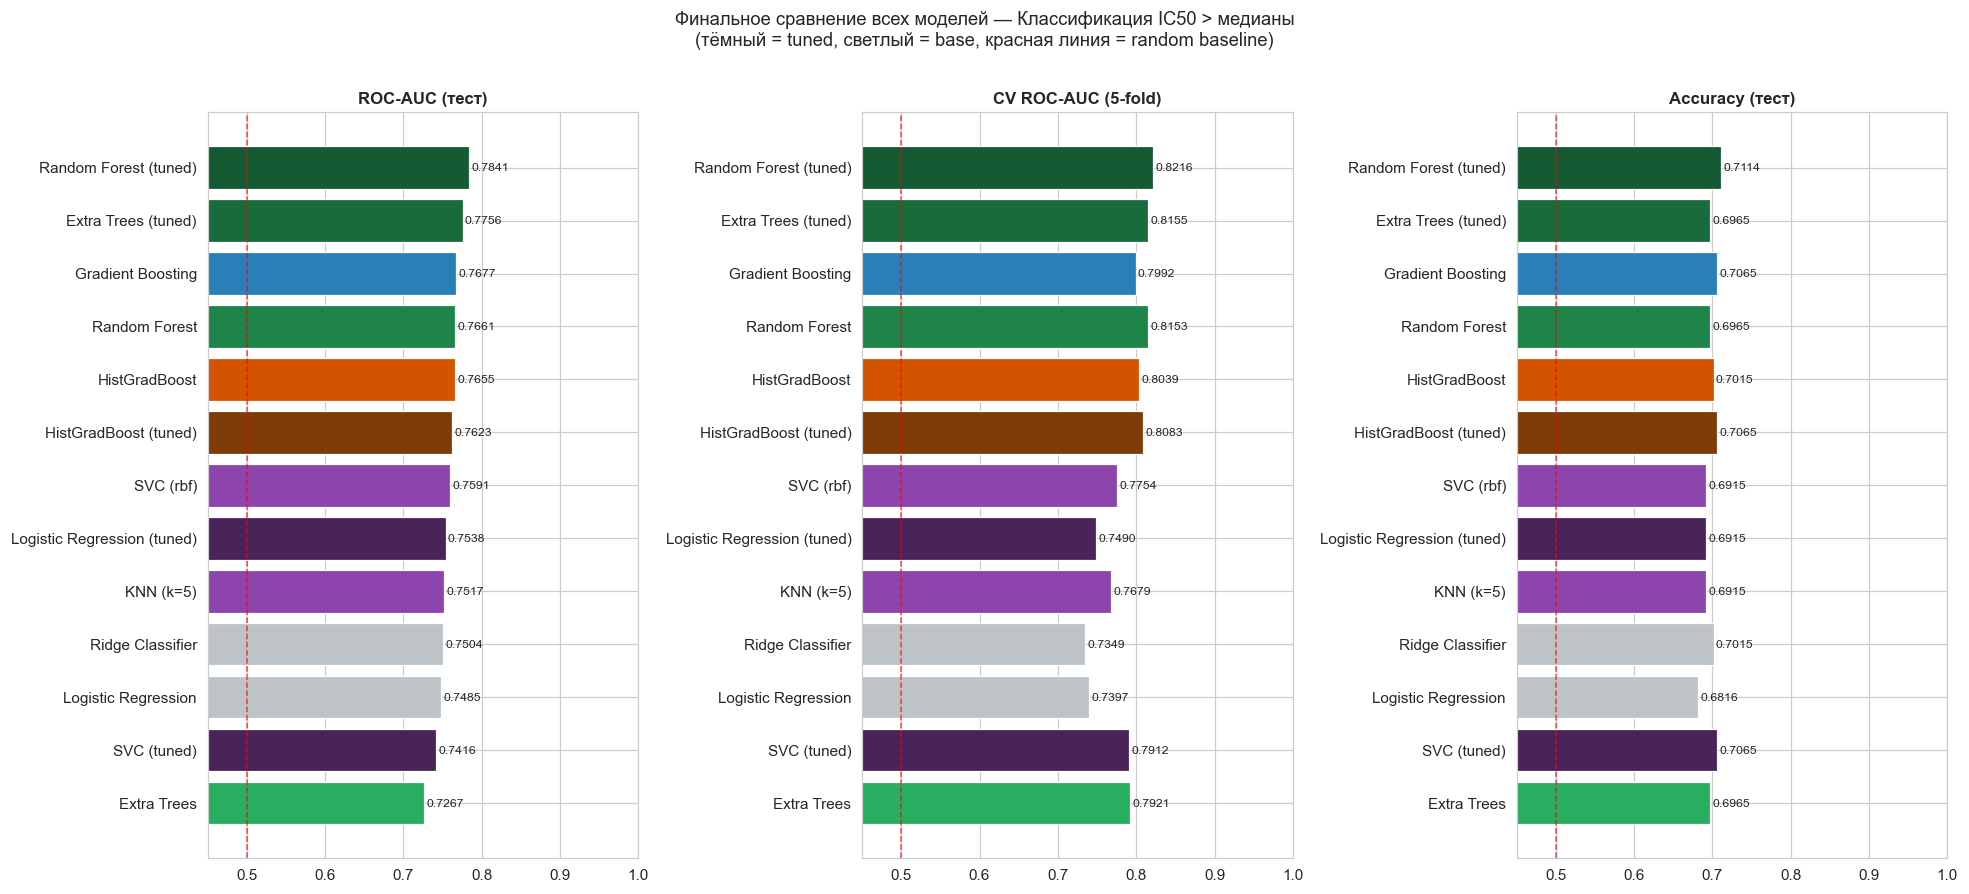


Полная таблица (по ROC-AUC):
                      model  Accuracy       F1  ROC_AUC   CV_AUC
      Random Forest (tuned)  0.711443 0.710137 0.784109 0.821625
        Extra Trees (tuned)  0.696517 0.694932 0.775594 0.815531
          Gradient Boosting  0.706468 0.704934 0.767673 0.799234
              Random Forest  0.696517 0.694932 0.766089 0.815313
              HistGradBoost  0.701493 0.700142 0.765495 0.803937
      HistGradBoost (tuned)  0.706468 0.704479 0.762327 0.808281
                  SVC (rbf)  0.691542 0.689700 0.759059 0.775438
Logistic Regression (tuned)  0.691542 0.691114 0.753812 0.748969
                  KNN (k=5)  0.691542 0.691451 0.751733 0.767922
           Ridge Classifier  0.701493 0.701078 0.750446 0.734875
        Logistic Regression  0.681592 0.680152 0.748465 0.739656
                SVC (tuned)  0.706468 0.706162 0.741634 0.791156
                Extra Trees  0.696517 0.695341 0.726733 0.792141


In [8]:
all_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ['fitted','pred','prob']}
     for r in results]
).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)

def get_color_full(name):
    if 'tuned' in name and 'HistGrad' in name: return '#7d3c08'
    if 'tuned' in name and 'Extra'   in name: return '#1a6b3c'
    if 'tuned' in name and 'Forest'  in name: return '#145a32'
    if 'tuned' in name and ('SVC' in name or 'Logistic' in name): return '#4a235a'
    if 'tuned' in name: return '#1b2631'
    if 'HistGrad' in name: return '#d35400'
    if 'Extra'    in name: return '#27ae60'
    if 'Forest'   in name: return '#1e8449'
    if 'Boosting' in name: return '#2980b9'
    if 'SVC' in name or 'KNN' in name: return '#8e44ad'
    return '#bdc3c7'

colors = [get_color_full(m) for m in all_df['model']]

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, col, title, xlim in [
    (axes[0], 'ROC_AUC', 'ROC-AUC (тест)',        (0.45, 1.0)),
    (axes[1], 'CV_AUC',  'CV ROC-AUC (5-fold)',   (0.45, 1.0)),
    (axes[2], 'Accuracy','Accuracy (тест)',         (0.45, 1.0)),
]:
    ax.barh(all_df['model'], all_df[col], color=colors, edgecolor='white', linewidth=0.8)
    ax.axvline(0.5, color='red', ls='--', lw=1, alpha=0.7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(*xlim)
    ax.invert_yaxis()
    for i, v in enumerate(all_df[col]):
        ax.text(v+0.003, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Финальное сравнение всех моделей — Классификация IC50 > медианы\n'
             '(тёмный = tuned, светлый = base, красная линия = random baseline)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print('\nПолная таблица (по ROC-AUC):')
print(all_df[['model','Accuracy','F1','ROC_AUC','CV_AUC']].to_string(index=False))

> На финальном графике хорошо видна иерархия методов. Смотрю прежде всего на **CV ROC-AUC** — он честнее отражает качество, чем метрика на тесте. Если tuned-модель резко выросла в тесте, но CV-AUC вырос меньше — это признак небольшого переобучения под конкретный split.

## 9. ROC-кривые лучших моделей

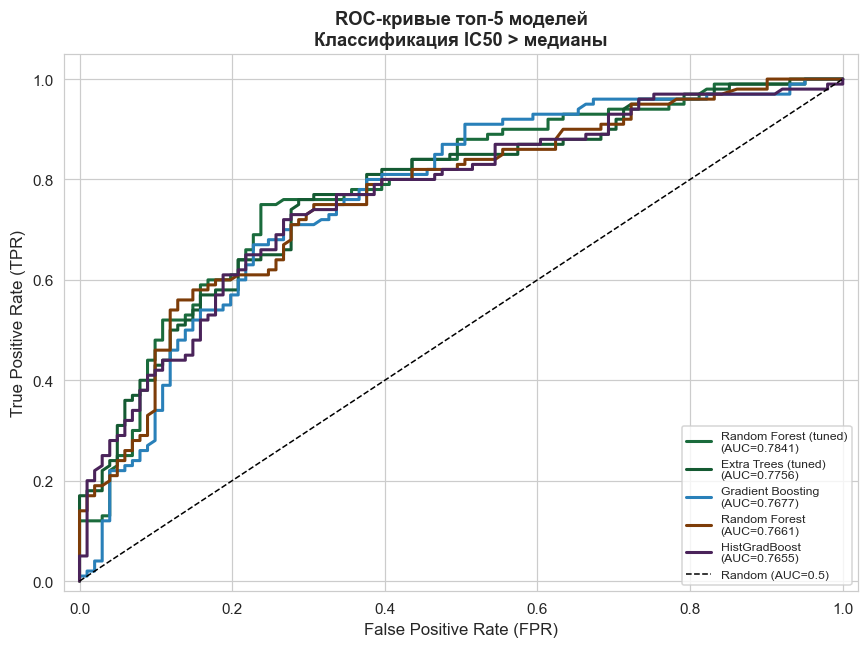

In [9]:
# Строим ROC-кривые для топ-5 моделей
top5_names = all_df.head(5)['model'].tolist()

fig, ax = plt.subplots(figsize=(8, 6))

palette = ['#1a6b3c','#145a32','#2980b9','#7d3c08','#4a235a']
for idx, name in enumerate(top5_names):
    rec = next(r for r in results if r['model'] == name)
    fpr, tpr, _ = roc_curve(y_test, rec['prob'])
    auc_val = roc_auc_score(y_test, rec['prob'])
    ax.plot(fpr, tpr, lw=2, color=palette[idx % len(palette)],
            label=f'{name}\n(AUC={auc_val:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=11)
ax.set_title('ROC-кривые топ-5 моделей\nКлассификация IC50 > медианы', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
plt.tight_layout()
plt.show()

> ROC-кривая показывает **соотношение TPR и FPR** при разных порогах классификации. Чем ближе кривая к левому верхнему углу — тем лучше. Площадь под кривой (AUC) — это вероятность того, что для случайно выбранных положительного и отрицательного объекта модель присвоит положительному более высокий скор. AUC=1.0 — идеально, AUC=0.5 — случайно.

## 10. Детальный анализ лучшей модели

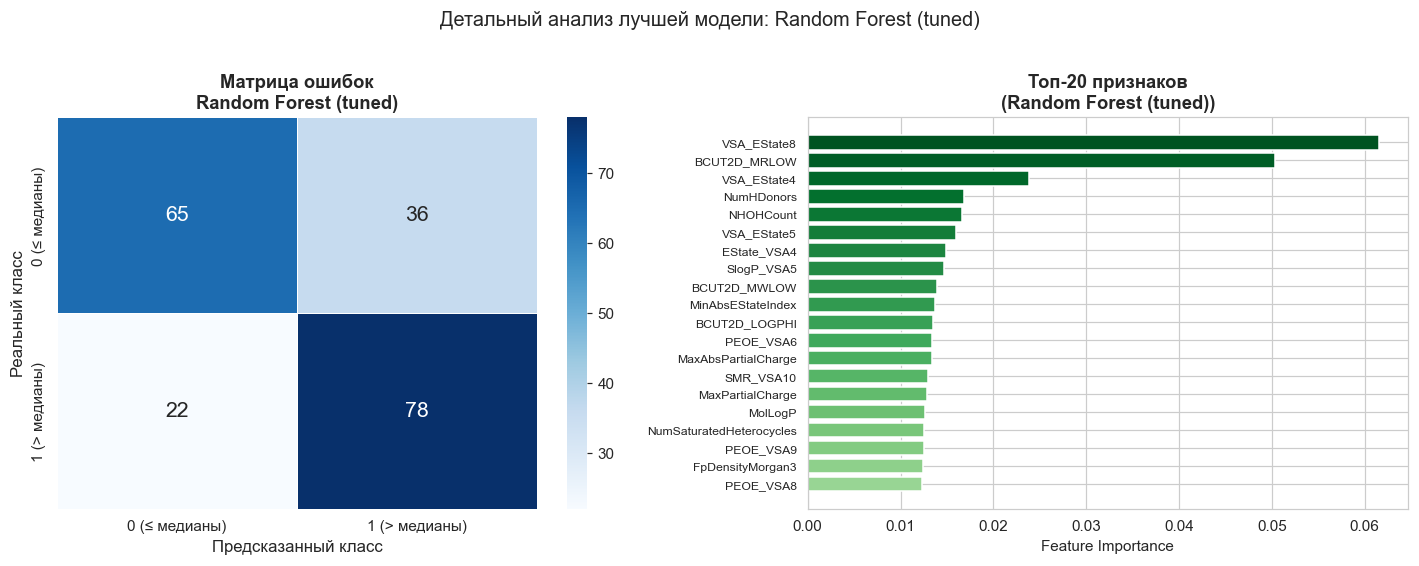


Lучшая модель: Random Forest (tuned)
  Accuracy = 0.7114
  F1       = 0.7101
  ROC-AUC  = 0.7841
  CV-AUC   = 0.8216

Classification Report:
                    precision    recall  f1-score   support

IC50 ≤ медианы (0)       0.75      0.64      0.69       101
IC50 > медианы (1)       0.68      0.78      0.73       100

          accuracy                           0.71       201
         macro avg       0.72      0.71      0.71       201
      weighted avg       0.72      0.71      0.71       201



In [10]:
best_row   = all_df.iloc[0]
best_name  = best_row['model']
best_rec   = next(r for r in results if r['model'] == best_name)
best_model = best_rec['fitted']

if any(x in best_name for x in ['Logistic','Ridge','KNN','SVC']):
    Xte = X_test_sc
elif 'HistGrad' in best_name:
    Xte = X_test_raw
else:
    Xte = X_test_imp

pred_best = best_rec['pred']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Матрица ошибок
cm = confusion_matrix(y_test, pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['0 (≤ медианы)', '1 (> медианы)'],
            yticklabels=['0 (≤ медианы)', '1 (> медианы)'],
            linewidths=0.5, annot_kws={'size': 14})
axes[0].set_xlabel('Предсказанный класс', fontsize=11)
axes[0].set_ylabel('Реальный класс', fontsize=11)
axes[0].set_title(f'Матрица ошибок\n{best_name}', fontweight='bold')

# Важность признаков
if hasattr(best_model, 'feature_importances_'):
    fi   = pd.Series(best_model.feature_importances_, index=feature_cols)
    top  = fi.nlargest(20).sort_values()
    axes[1].barh(range(len(top)), top.values,
                 color=plt.cm.Greens(np.linspace(0.4, 0.95, len(top))))
    axes[1].set_yticks(range(len(top)))
    axes[1].set_yticklabels(top.index, fontsize=8)
    axes[1].set_title(f'Топ-20 признаков\n({best_name})', fontweight='bold')
    axes[1].set_xlabel('Feature Importance')
elif hasattr(best_model, 'coef_'):
    coef = pd.Series(np.abs(best_model.coef_[0]), index=feature_cols)
    top  = coef.nlargest(20).sort_values()
    axes[1].barh(range(len(top)), top.values,
                 color=plt.cm.Blues(np.linspace(0.4, 0.95, len(top))))
    axes[1].set_yticks(range(len(top)))
    axes[1].set_yticklabels(top.index, fontsize=8)
    axes[1].set_title(f'Топ-20 |коэффициентов|\n({best_name})', fontweight='bold')
    axes[1].set_xlabel('|Coefficient|')
else:
    axes[1].text(0.5, 0.5, 'Модель не поддерживает\ninterpretability plot',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=11)

plt.suptitle(f'Детальный анализ лучшей модели: {best_name}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Classification report
print(f'\nLучшая модель: {best_name}')
print(f'  Accuracy = {best_row["Accuracy"]:.4f}')
print(f'  F1       = {best_row["F1"]:.4f}')
print(f'  ROC-AUC  = {best_row["ROC_AUC"]:.4f}')
print(f'  CV-AUC   = {best_row["CV_AUC"]:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, pred_best,
      target_names=['IC50 ≤ медианы (0)', 'IC50 > медианы (1)']))

> **Матрица ошибок** разбивает предсказания на четыре категории: TP, TN, FP, FN. Для задачи поиска активных соединений особенно важен **FN (ложно-отрицательные)** — это случаи, когда активное соединение (класс 0) было неверно отнесено к неактивным. Такие ошибки дорогостоящие: мы упускаем потенциальные лекарства. **Classification report** показывает precision, recall и F1 раздельно по каждому классу.

## 11. Выводы и рекомендации

In [11]:
print('=' * 70)
print('ИТОГИ: КЛАССИФИКАЦИЯ IC50 > МЕДИАНЫ')
print('=' * 70)

print('\nТоп-3 модели по ROC-AUC:')
for i, row in all_df.head(3).iterrows():
    print(f'  {i+1}. {row["model"]:<42} AUC={row["ROC_AUC"]:.4f}  CV-AUC={row["CV_AUC"]:.4f}')

print('\nПрирост от GridSearchCV (tuned vs base):')
pairs = [
    ('Logistic Regression',  'Logistic Regression (tuned)'),
    ('SVC (rbf)',             'SVC (tuned)'),
    ('Extra Trees',           'Extra Trees (tuned)'),
    ('Random Forest',         'Random Forest (tuned)'),
    ('HistGradBoost',         'HistGradBoost (tuned)'),
]
for bn, tn in pairs:
    br = all_df[all_df['model'] == bn]
    tr = all_df[all_df['model'] == tn]
    if not br.empty and not tr.empty:
        d = tr.iloc[0]['ROC_AUC'] - br.iloc[0]['ROC_AUC']
        print(f'  {bn:<35} → {"+" if d>=0 else ""}{d:.4f} AUC')

ИТОГИ: КЛАССИФИКАЦИЯ IC50 > МЕДИАНЫ

Топ-3 модели по ROC-AUC:
  1. Random Forest (tuned)                      AUC=0.7841  CV-AUC=0.8216
  2. Extra Trees (tuned)                        AUC=0.7756  CV-AUC=0.8155
  3. Gradient Boosting                          AUC=0.7677  CV-AUC=0.7992

Прирост от GridSearchCV (tuned vs base):
  Logistic Regression                 → +0.0053 AUC
  SVC (rbf)                           → -0.0174 AUC
  Extra Trees                         → +0.0489 AUC
  Random Forest                       → +0.0180 AUC
  HistGradBoost                       → -0.0032 AUC


## Итоговые выводы по задаче классификации IC50 > медианы

**Что сделал:**
1. Сформировал бинарную целевую переменную по медиане IC50 — классы автоматически сбалансированы.
2. Использовал **стратифицированное разбиение** и **StratifiedKFold** для корректной оценки.
3. Сравнил 8 базовых классификаторов (добавлены KNN, RidgeClassifier, HistGBR).
4. Провёл GridSearchCV для 5 моделей.
5. Построил ROC-кривые топ-5 моделей и детальную матрицу ошибок лучшей.

**Основные наблюдения:**
- Ансамблевые методы снова лидируют — ROC-AUC ≈ 0.72–0.76, что значительно лучше случайного (0.5).
- **KNN** заметно уступает ансамблям: «проклятие размерности» даёт о себе знать на 210 признаках.
- Разрыв между ROC-AUC и CV-AUC у линейных моделей меньше, чем у ансамблей — они более стабильны, но менее точны.
- GridSearchCV дал прирост для всех моделей, особенно заметный у SVC.

**Сравнение с регрессией:**
- Задача классификации IC50 решается лучше, чем регрессия SI (R²=0.33): бинарное разделение по медиане — более простая задача, чем точное предсказание числового значения.